In [3]:
import sys
sys.path.append("../../src")

from spice.models import IcosphereModel
from spice.models.mesh_transform import add_rotation, evaluate_rotation
from spice.models.spots import add_spots
from spice.plots import plot_3D
from spice.spectrum import simulate_observed_flux
import astropy.units as u
import jax.numpy as jnp
import numpy as np
from transformer_payne import TransformerPayne
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm

from jax import vmap

In [4]:
from spice.spectrum.lazy_zarr_grid_interpolator import LazyZarrGridInterpolator

ZARR_PATH = "/Users/mjablons/Documents/spice/ca_triplet.zarr"
interpolator = LazyZarrGridInterpolator(ZARR_PATH)

Opening lazy spectral grid from /Users/mjablons/Documents/spice/ca_triplet.zarr (chunk_rows=500; initialization indexes metadata instead of loading dense flux cubes)
Opening lazy zarr store at /Users/mjablons/Documents/spice/ca_triplet.zarr (chunk_rows=500; lazy init reads metadata/indexes only)
Lazy grid loader init 1/4 complete after 28.92 s (rough total 1m 55.7s, remaining 1m 26.8s): store opened and metadata targets located | flux_shape=(28704, 4001), continuum_shape=(28704, 4001), metadata_to_read=1.22 MiB
Loaded lazy index cache from disk at /Users/mjablons/Documents/spice/ca_triplet.zarr.spice_lazy_index_cache.npz
Lazy grid loader init 2/4 complete after 42.37 s (rough total 1m 24.7s, remaining 42.37 s): metadata cache hit | source=disk, rows=28704, wavelengths=4001, params_shape=(28704, 10), mu_selected=present
Lazy grid loader init 3/4 complete after 42.37 s (rough total 56.50 s, remaining 14.12 s): cached parameter axes restored | axes=['logg', 'teff', 'feh', 'vmicro'], grid_

In [6]:
m = IcosphereModel.construct(5000, 1., 1.,
                             interpolator.to_parameters(),
                             interpolator.stellar_parameter_names)

In [7]:
interpolator.stellar_parameter_names

['logg', 'teff', 'feh', 'vmicro']

In [9]:
from spice.models.utils import lat_to_theta, lon_to_phi, velocity_to_period

period_seconds = velocity_to_period(20., m.radius)
timestamps = jnp.linspace(0, period_seconds, 100)
mt = add_rotation(m, 20.)

SPOT_RADIUS = 90.

ms = add_spots(mt,
               spot_center_thetas=jnp.array([lat_to_theta(lat_deg) for lat_deg in [0]]),
               spot_center_phis=jnp.array([lon_to_phi(lon_deg) for lon_deg in [90]]),
               spot_radii=jnp.array([SPOT_RADIUS]),
               parameter_deltas=jnp.array([-500]),
               parameter_indices=jnp.array([1]),
               smoothness=jnp.array([0.5]))

mts = [evaluate_rotation(ms, t) for t in tqdm(timestamps)]

100%|██████████| 100/100 [00:00<00:00, 4059.61it/s]


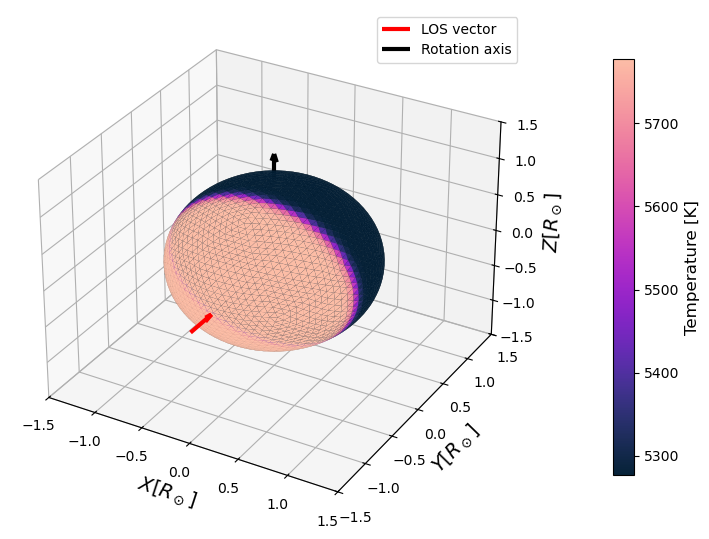

In [10]:
fig, _ = plot_3D(mts[0], 1, property_label='Temperature [K]');

In [12]:
vws = jnp.linspace(8400, 8800, 200)
spec = []
for mt in tqdm(mts):
    spec.append(simulate_observed_flux(interpolator.intensity, mt, jnp.log10(vws)))

  0%|          | 0/100 [00:03<?, ?it/s]


TypeError: isinstance() arg 2 must be a type, a tuple of types, or a union